In [1]:
# import time
# from tqdm.notebook import tqdm
import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
from h5 import HDFArchive

from triqs.atom_diag import AtomDiagComplex
from triqs.operators import n, c, c_dag
from itertools import product
from triqs.plot.mpl_interface import oplot
from triqs.utility.comparison_tests import *

import sys
sys.path.append("../")
from sort import sort_states_full
from three_pt_corr import *
from four_pt_corr import *
from four_pt_corr_v2 import FourPtCorr as FourPtCorr_v2

from itertools import product

In [13]:
# Number of bosonic Matsubara frequencies for susceptibility calculation
bn_iw = 10
# Number of fermionic Matsubara frequencies for susceptibility calculation
fn_iw = 10

beta = 2.0             # Inverse temperature

biw_mesh = MeshImFreq(beta = beta, statistic = 'Boson', n_iw = bn_iw)
fiw_mesh = MeshImFreq(beta = beta, statistic = 'Fermion', n_iw = fn_iw)

In [14]:
# Hubbard atom

####################
# Input parameters #
####################

# eps = [-1.9, -2.1]      # Energy levels of the atoms
# h_field = 0.05          # Magnetic field
U = 4.0                 # Coulomb repulsion
mu = U/2              # Chemical potential    
atoms = (0,)

spin_names = ("up", "dn")

# H = sum(e * n(s, a) for (a, e), s in product(zip(atoms, eps), spin_names))
# H += sum(-h_field * (n('up', a) - n('dn', a)) for a in atoms)
H = U * n('up', 0) * n('dn', 0)
H += -mu * sum(n(s,0) for s in spin_names)

fops = [('up',0), ('dn',0)]

In [15]:
ad = AtomDiagComplex(H, fops)

In [16]:
ad.gs_energy

-1.8

In [17]:
eigensys = sort_states_full(spin_names, atoms, ad)

states in subspace  0 : 
| 01 >
states in subspace  1 : 
| 10 >
states in subspace  2 : 
| 00 >
states in subspace  3 : 
| 11 >
Finished sorting states


In [18]:
print(eigensys[1])

[[array([1.-0.j]), ['10']], np.float64(0.0), 1]


# 3 Point Function

In [9]:
# from importlib import reload

# import three_pt_corr
# reload(three_pt_corr)

# from three_pt_corr import *

## <c_dag(t1)c(t1)c_dag(t_2)c(0)>

In [11]:
%%time

# G_iw = dict()
ops = [(c_dag('up', 0)*c('up', 0), 'Boson'),
       (c_dag('up',0), 'Fermion'),
       (c('up', 0), 'Fermion')]

corr = ThreePtCorr(ops = ops, hamiltonian = (ad, eigensys))

# G = corr.G_div_diff_iw(beta = beta, n_iw = [10,10])
G_iw = corr.G_div_diff_iw(beta = beta, n_iw = [10,1000])
    

CPU times: user 369 ms, sys: 1.01 ms, total: 370 ms
Wall time: 741 ms


In [98]:
# with HDFArchive("ncdagc_10_3000", 'w') as A:
#     A['beta'] = beta
#     A['chi3'] = G_iw
#     A['spin'] = 'up up up up'

In [13]:
# Integrate over the first frequency
fiw_mesh = MeshImFreq(beta = beta, statistic = 'Fermion', n_iw = 1000)

G_int1 = Gf(mesh = biw_mesh, target_shape = [])
G_int1.zero()

for iw1 in biw_mesh:
    for iw2 in fiw_mesh:
        G_int1[iw1] += G_iw[iw1,iw2]

# oplot(G_int1['0000'])

## <c_dag(t1)c(t2)c_dag(0)c(0)>

In [75]:
for s, s2 in list(product(spin_names, repeat = 2)):
    print(s, s2)

up up
up dn
dn up
dn dn


In [79]:
%%time

G_iw = dict()

for s1, s2 in list(product(spin_names, repeat = 2)):
    ops = [(c_dag(s1, 0), 'Fermion'),
           (c(s1,0), 'Fermion'),
           (c_dag(s2, 0)*c(s2,0), 'Boson')]

    corr = ThreePtCorr(ops = ops, hamiltonian = (ad, eigensys))

    G_iw[s1+s2] = corr.G_div_diff_iw(beta = beta, n_iw = [20,20])

CPU times: user 63.8 ms, sys: 0 ns, total: 63.8 ms
Wall time: 66 ms


In [82]:
# Integrate over the first frequency

fiw_mesh = MeshImFreq(beta = beta, statistic = 'Fermion', n_iw = 20)
G_int1 = dict()

for s1, s2 in list(product(spin_names, repeat = 2)):
    G = Gf(mesh = fiw_mesh, target_shape = [])
    G.zero()
    for iw2 in fiw_mesh:
        for iw1 in fiw_mesh:
            G[iw2] += G_iw[s1+s2][iw1,iw2]
            G_int1[s1+s2] = G


# oplot(G_int1['0000'])

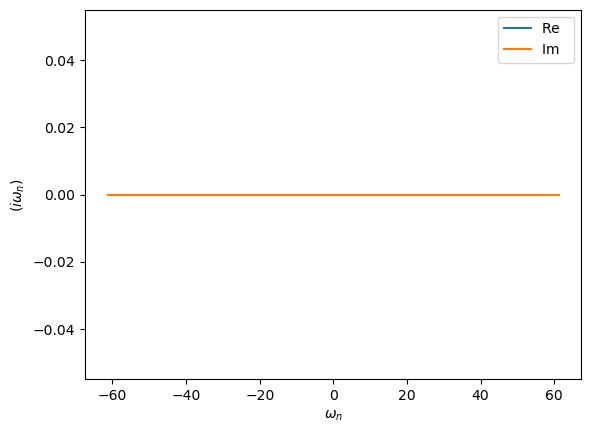

In [84]:
oplot(-G_int1['updn'] + G_int1['dnup'])

In [23]:
div_diff = HDFArchive("dimer_chi3_div_diff.h5", 'w')

for x, y, z, w in product(range(2),repeat=4):
    div_diff["G_int1"] = G_int1

# Pomerol 2 Point Function

In [224]:
ref = HDFArchive("pomerol_ref.h5", 'r')
print(ref)

HDFArchive (partial view) with the following content:
  0000 : subgroup
  0001 : subgroup
  0010 : subgroup
  0011 : subgroup
  0100 : subgroup
  0101 : subgroup
  0110 : subgroup
  0111 : subgroup
  1000 : subgroup
  1001 : subgroup
  1010 : subgroup
  1011 : subgroup
  1100 : subgroup
  1101 : subgroup
  1110 : subgroup
  1111 : subgroup
  chi3_ph_AABB : subgroup


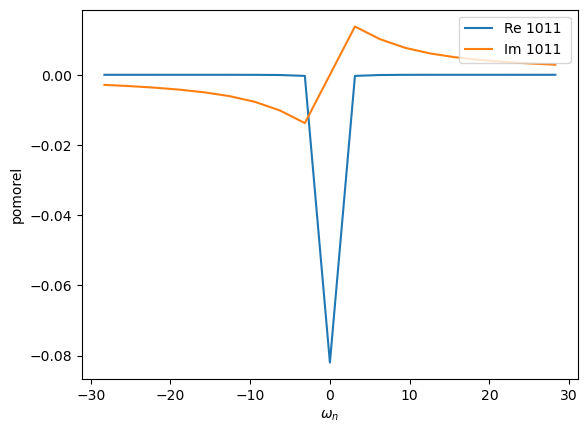

In [225]:
s = '1011'
oplot(ref[s], ylabel = 'pomorel')

In [238]:
print(biw_mesh[8].value.value)
print(biw_mesh[10].value.value)
print(ref[s][biw_mesh[8]])
print(ref[s][biw_mesh[10]])

-3.141592653589793j
3.141592653589793j
(-0.0003086971755104079-0.013756260782095594j)
(-0.0003086971755104079+0.013756260782095594j)


In [242]:
print(biw_mesh[8].value.value)
print(biw_mesh[10].value.value)
print(-G_int1[s][biw_mesh[8]]/beta)
print(-G_int1[s][biw_mesh[10]]/beta)

-3.141592653589793j
3.141592653589793j
(-0.0003087079278201687-0.013755879606232993j)
(-0.000308707927820168+0.013755879606233038j)


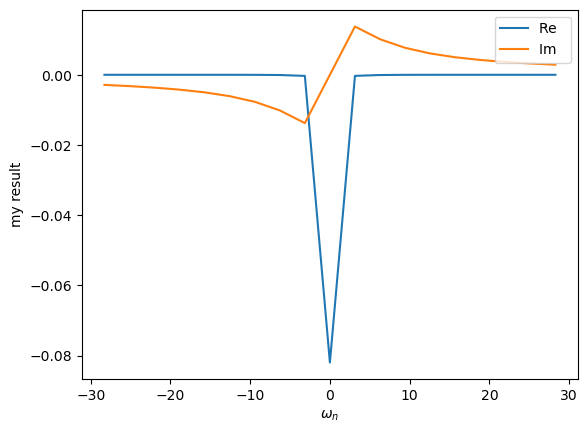

In [169]:
G = -G_int1[s].copy()/beta
G[biw_mesh[9]] = ref[s][biw_mesh[9]]
oplot(G, ylabel = 'my result')

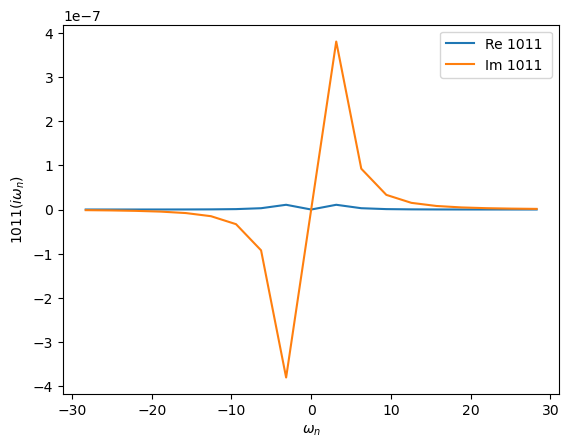

In [170]:
oplot(ref[s]-G)
# print((ref[s][biw_mesh[10]]+G_int1[s][biw_mesh[10]]/beta).real)

In [136]:
biw_mesh[9].value.value

0j

# Pomerol 3 Point Function

In [23]:
ref = HDFArchive("pomerol_ref.h5", 'r')
print(type(ref["chi3_ph_AABB"]))

G_ref = ref['chi3_ph_AABB']["up","up"]

fiw_mesh = MeshImFreq(beta = beta, statistic = 'Fermion', n_iw = 20)
biw_mesh = MeshImFreq(beta = beta, statistic = 'Boson', n_iw = 20)

G_ref_int1 = Gf(mesh = fiw_mesh, target_shape = [])
G_ref_int1.zero()

for iw2 in fiw_mesh:
    for iw1 in biw_mesh:
        G_ref_int1[iw2] += G_ref[iw1,iw2]

# oplot(-G_ref)

<class 'triqs.gf.block2_gf.Block2Gf'>


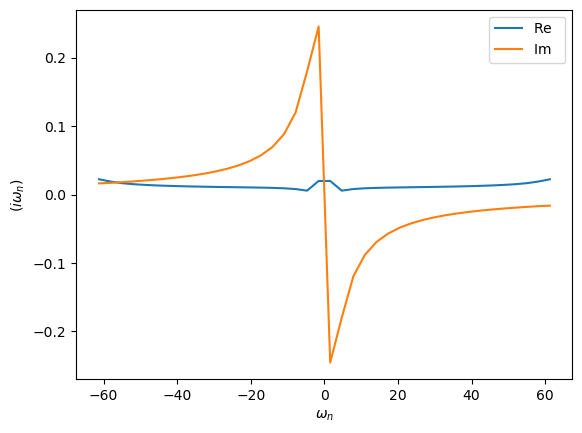

In [24]:
oplot(G_ref_int1)

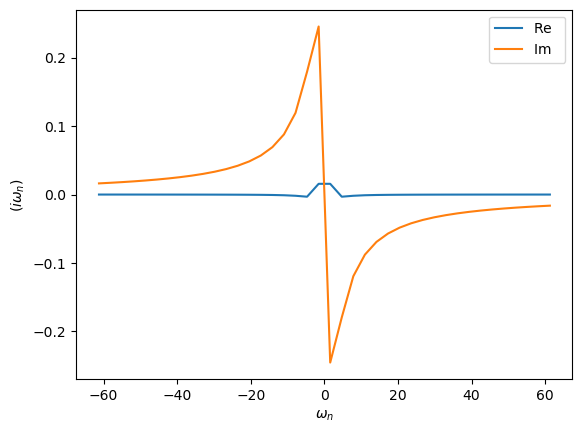

In [25]:
oplot(-G_int1)

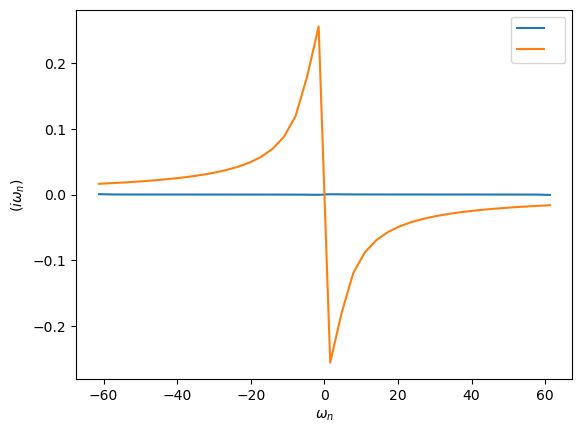

In [223]:
oplot(G_ref.imag+G_int1['0000'].imag)
oplot(-G_int1['0000'].imag)

In [207]:
G_ref[fiw_mesh[9]].real+G_int1['0000'][fiw_mesh[9]].real

np.float64(0.00916896436805685)

In [28]:
ref2 = HDFArchive("dimer_chi3.ref.h5", 'r')
print(ref2)

HDFArchive (partial view) with the following content:
  H : data 
  chi3_ph_AABB : subgroup
  chi3_ph_ABBA : subgroup
  chi3_pp_AABB : subgroup
  chi3_pp_ABBA : subgroup
  chi3_xph_AABB : subgroup
  chi3_xph_ABBA : subgroup


In [34]:
for bn1, bn2 in product(spin_names, spin_names):
    assert_gfs_are_close(ref['chi3_ph_AABB'][bn1, bn2], ref2['chi3_ph_AABB'][bn1, bn2])

# Analytic 3 Point Function

In [57]:
from triqs.gf.descriptor_base import Function

fiw_mesh = MeshImFreq(beta = beta, statistic = 'Fermion', n_iw = 20)

# Bare propagator
G0 = Gf(mesh = fiw_mesh, target_shape = [])
G0 << Function(lambda x: x- (U*U)/(4*x))
G0.invert()

prod_mesh = MeshProduct(fiw_mesh,fiw_mesh)

# Pi(iw1,iw2) = G0(iw1)*G0(iw2)
Pi = Gf(mesh = prod_mesh, target_shape = [])
for i in range(len(fiw_mesh)):
    for j in range(len(fiw_mesh)):
        Pi[fiw_mesh[i],fiw_mesh[j]] = G0[fiw_mesh[i]]*G0[fiw_mesh[j]]


n_F_U = 1/(1 + np.exp(beta * U))

In [61]:
chi3 = Gf(mesh = prod_mesh, target_shape = [])
chi3 = Pi.copy()
chi3.zero()

# chi3(iw1,-iw1) = -beta * U * n_F(U) * (1 + U^2/4w1^2) Pi(iw1,-iw1)
for i in range(len(fiw_mesh)):
    w = fiw_mesh[i].value.value
    chi3[fiw_mesh[i], fiw_mesh[2*n_iw-1-j]] = -beta * U * n_F_U * (1 - (U*U)/(4*w*w))*Pi[fiw_mesh[i],fiw_mesh[2*n_iw-1-j]]


In [62]:
G_ana_int1 = Gf(mesh = fiw_mesh, target_shape = [])
G_ana_int1.zero()

for iw2 in fiw_mesh:
    for iw1 in fiw_mesh:
        G_ana_int1[iw2] += chi3[iw1,iw2]

# oplot(-G_ref)

In [70]:
G = Gf(mesh = fiw_mesh, target_shape = [])
for i in range(len(fiw_mesh)):
    w = fiw_mesh[i].value.value
    G[fiw_mesh[i]] = -beta * U * n_F_U * (1 - (U*U)/(4*w*w))*Pi[fiw_mesh[i],fiw_mesh[2*n_iw-1-j]]

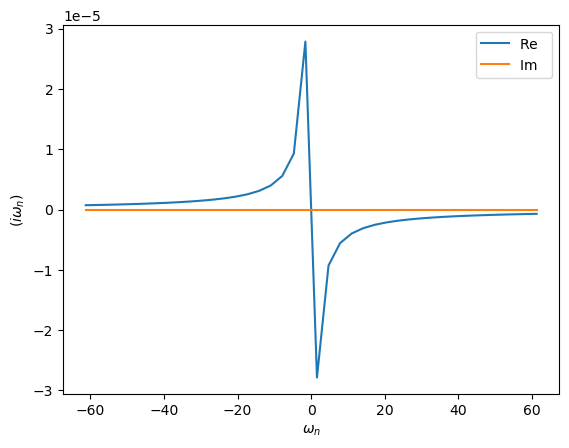

In [71]:
oplot(G)

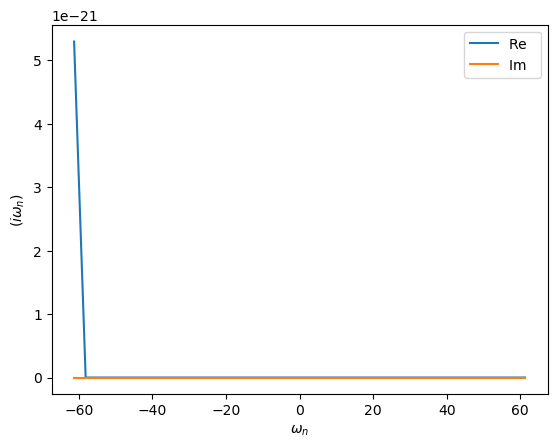

In [63]:
oplot(G_ana_int1)

# 4 Point Function

In [26]:
%%time

ops = [(c_dag('up', 0), 'Fermion'),
       (c('up',0), 'Fermion'),
       (c('up', 0), 'Fermion'),
       (c_dag('up', 0), 'Fermion')]

corr = FourPtCorr(ops = ops, hamiltonian = (ad, eigensys))

G = corr.G_div_diff_iw(beta = beta, n_iw = [5,5,5])

start numerical calculations
CPU times: user 1min 5s, sys: 174 ms, total: 1min 5s
Wall time: 1min 5s


In [55]:
%%time

ops = [(c_dag('up', 0), 'Fermion'),
       (c('up',0), 'Fermion'),
       (c('up', 0), 'Fermion'),
       (c_dag('up', 0), 'Fermion')]

corr = FourPtCorr_v2(ops = ops, hamiltonian = (ad, eigensys))

G = corr.G_div_diff_iw(beta = beta, n_iw = [5,5,5])

start numerical calculations
CPU times: user 17.1 s, sys: 41 ms, total: 17.2 s
Wall time: 17.3 s


In [61]:
A = HDFArchive("plaq_4pt.h5", 'r')
print(A["G"].mesh)

Imaginary Freq Mesh with beta = 2, statistic = Fermion, n_iw = 10, positive_only = false, Imaginary Freq Mesh with beta = 2, statistic = Fermion, n_iw = 10, positive_only = false, Imaginary Freq Mesh with beta = 2, statistic = Fermion, n_iw = 10, positive_only = false


In [2]:
import numpy as np